# Lead–Lag Feature Engineering for Early Outbreak Detection

This notebook implements the lead–lag feature engineering framework used to identify early-warning signals of H5N1 outbreaks from online discourse. The objective is not to predict outbreak occurrence directly, but to detect **temporal patterns in social signals that consistently precede official outbreak confirmation**.

Digital epidemiological signals—such as stigma, sentiment, and topic prevalence—rarely manifest as instantaneous reactions. Instead, they emerge through **gradual buildup, persistence, and short-horizon escalation** prior to confirmed events. Capturing these dynamics requires explicitly modeling *when* signals occur relative to outbreaks and *how long* they persist.

To address this, we transform raw daily discourse features into **time-aware representations** using:
- **Lagged features**, which encode temporal precedence (lead effects), and
- **Rolling averages**, which encode persistence and momentum.

These features are constructed at the **country–day level** and aligned to outbreak confirmation dates using an event-study framework. The resulting feature set enables downstream models to distinguish anticipatory behavioral signals from post-event reactions, while preserving interpretability and causal plausibility.

This notebook documents each step of the lead–lag feature engineering process in detail.


In [42]:
import pandas as pd

## Load and Inspect Aggregated Discourse Data

We begin by loading the country–day aggregated dataset containing stigma proportions, sentiment polarity, and topic prevalence. Each row represents a single country–day observation derived from social media posts.

At this stage, the data are **static snapshots** and do not yet encode temporal structure.


In [43]:
# Apply to your dataset
df = pd.read_csv("merged_output_with_stigma_ohe_sentiment.csv")
df.head()

,activities,content_type,creation_time,id,is_branded_content,lang,link_attachment.caption,link_attachment.description,link_attachment.link,link_attachment.name,...,stigma_label,stigma_fear,stigma_humor,stigma_neutral,stigma_urgency,stigma_fear.1,stigma_humor.1,stigma_neutral.1,stigma_urgency.1,sentiment
0,NaN,status,2025-11-10T19:00:19+00:00,2980185815499999,False,en,NaN,NaN,NaN,NaN,...,fear,True,False,False,False,True,False,False,False,-0.243182
1,NaN,albums,2025-11-10T18:23:30+00:00,686591307858179,False,ro,NaN,NaN,NaN,NaN,...,fear,True,False,False,False,True,False,False,False,0.000000
2,NaN,videos,2025-11-10T18:14:12+00:00,1006177595025072,False,en,NaN,NaN,NaN,NaN,...,fear,True,False,False,False,True,False,False,False,-0.075000
3,NaN,links,2025-11-10T16:24:10+00:00,840171035327111,False,en,brecon-radnor.co.uk,NaN,https://www.brecon-radnor.co.uk/news/farming/a...,Avian influenza confirmed at Powys premises,...,neutral,False,False,True,False,False,False,True,False,0.280000
4,NaN,links,2025-11-10T16:05:06+00:00,1028189766103347,False,de,promisundmehr.de,"Promis, Prominente, Stars und Sternchen ... Di...",https://www.promisundmehr.de/vogelgrippe-bei-h...,Vogelgrippe bei Haustieren: Katzen sind potenz...,...,fear,True,False,False,False,True,False,False,False,0.000000


In [65]:
df_en[["stigma_label", "clean_text"]].groupby("stigma_label", group_keys=False).apply(lambda x: x.sample(min(5, len(x)), random_state=42)).reset_index(drop=True).head()


/var/folders/3t/knnqplg16hv03_0h31dy9sdw0000gq/T/ipykernel_52019/4030375526.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_en[["stigma_label", "clean_text"]].groupby("stigma_label", group_keys=False).apply(lambda x: x.sample(min(5, len(x)), random_state=42)).reset_index(drop=True).head()


,stigma_label,clean_text
0,fear,in an updated report on 70 laboratory-confirme...
1,fear,🌊🐧 tracking avian influenza in antarctica 🦠🔍\n...
2,fear,an 11-year-old boy from gurugram was reported ...
3,fear,experts warn h5n1 bird flu could spark a pande...
4,fear,"the state of the bird flu virus, or h5n1, has ..."


In [10]:
gt = pd.read_csv("improved_h5n1_ground_truth.csv")
gt["date"] = pd.to_datetime(gt["date"]).dt.date
gt["date"] = pd.to_datetime(gt["date"])

In [11]:
gt.columns

Index(['date', 'country', 'gdelt_signal', 'promed_signal', 'animal_case',
       'human_case', 'fused_outbreak'],
      dtype='object')

In [9]:
gt.head(5)

,date,country,label
0,2017-01-01,Australia,0
1,2017-01-01,Bahrain,0
2,2017-01-01,Bangladesh,0
3,2017-01-01,Bhutan,0
4,2017-01-01,Brunei,0


In [146]:
stigma = pd.read_csv("merged_output_with_stigma_ohe_sentiment.csv")
stigma["date"] = pd.to_datetime(stigma["creation_time"])
#stigma["inferred_country"] = stigma["inferred_country"].astype(str).str.strip()

gt["country"] = gt["country"].astype(str).str.strip()
stigma["inferred_country"] = stigma["inferred_country"].astype(str).str.strip()


In [147]:
# ========================
# FULL DAILY GRID
# ========================
all_countries = stigma["inferred_country"].unique()
all_dates = pd.date_range(stigma["date"].min(), stigma["date"].max(), freq="D")

calendar = (
    pd.MultiIndex.from_product([all_dates, all_countries], names=["date","country"])
    .to_frame(index=False)
)

calendar.columns

Index(['date', 'country'], dtype='object')

In [148]:
gt_daily = (
    gt.groupby(["date","country"], as_index=False)
      .agg({"fused_outbreak":"max"})
)

calendar.dtypes

date       datetime64[ns, UTC]
country                 object
dtype: object

In [149]:
calendar["date"] = pd.to_datetime(calendar["date"]).dt.date
gt_daily["date"] = pd.to_datetime(gt_daily["date"]).dt.date

In [150]:
gt_full = calendar.merge(gt_daily, on=["date","country"], how="left")
gt_full["fused_outbreak"] = gt_full["fused_outbreak"].fillna(0).astype(int)

In [151]:
gt_full["fused_outbreak"] == 1

0         False
1         False
2         False
3         False
4         False
          ...  
161795    False
161796    False
161797    False
161798    False
161799    False
Name: fused_outbreak, Length: 161800, dtype: bool

In [152]:
# ========================
# EARLY-WARNING LABELING: 30 DAYS BEFORE OUTBREAK
# ========================
early_window = 30
gt_full = gt_full.sort_values(["country","date"])
gt_full.columns

Index(['date', 'country', 'fused_outbreak'], dtype='object')

In [153]:
gt_full["early_warning"] = 0

for c in gt_full["country"].unique():
    df = gt_full[gt_full["country"] == c]
    outbreak_dates = df[df["fused_outbreak"] == 1]["date"].values
    for od in outbreak_dates:
        mask = (df["date"] >= od - pd.Timedelta(days=early_window)) & \
               (df["date"] < od)
        gt_full.loc[df.index[mask], "early_warning"] = 1

In [154]:
gt_full.head(5)

,date,country,fused_outbreak,early_warning
37,2017-01-01,Australia,0,0
87,2017-01-02,Australia,0,0
137,2017-01-03,Australia,0,0
187,2017-01-04,Australia,0,0
237,2017-01-05,Australia,0,0


In [155]:
gt_full[gt_full["early_warning"] == 1].head(5)

,date,country,fused_outbreak,early_warning
51887,2019-11-04,Australia,0,1
51937,2019-11-05,Australia,0,1
51987,2019-11-06,Australia,0,1
52037,2019-11-07,Australia,0,1
52087,2019-11-08,Australia,0,1


In [156]:
gt_full.info()
gt_full.head()

<class 'pandas.core.frame.DataFrame'>
Index: 161800 entries, 37 to 161799
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   date            161800 non-null  object
 1   country         161800 non-null  object
 2   fused_outbreak  161800 non-null  int64 
 3   early_warning   161800 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 10.2+ MB


,date,country,fused_outbreak,early_warning
37,2017-01-01,Australia,0,0
87,2017-01-02,Australia,0,0
137,2017-01-03,Australia,0,0
187,2017-01-04,Australia,0,0
237,2017-01-05,Australia,0,0


In [157]:
#gt_full["date"] = pd.to_datetime(gt_full["date"]).dt.date
gt_full["date"] = pd.to_datetime(gt_full["date"], errors="coerce", format="%Y-%m-%d")
#gt_full["date"] = gt_full["date"].dt.date
gt_full.dtypes


date              datetime64[ns]
country                   object
fused_outbreak             int64
early_warning              int64
dtype: object

In [158]:
stigma.dtypes

activities                                          float64
content_type                                         object
creation_time                                        object
id                                                    int64
is_branded_content                                     bool
lang                                                 object
link_attachment.caption                              object
link_attachment.description                          object
link_attachment.link                                 object
link_attachment.name                                 object
match_type                                           object
mcl_url                                              object
modified_time                                        object
multimedia                                           object
post_owner.id                                        object
post_owner.name                                      object
post_owner.type                         

In [159]:
gt_full["date"] = pd.to_datetime(gt_full["date"]).dt.tz_localize(None)
stigma["date"] = pd.to_datetime(stigma["date"]).dt.tz_localize(None)


In [166]:
gt_full["country_normalized"] = gt_full["country"].str.lower().str.strip()
stigma["country_normalized"] = stigma["inferred_country"].str.lower().str.strip()

In [209]:
# ========================
# MERGE WITH STIGMA
# ========================
merged = stigma.merge(
    gt_full,
    left_on=["date","country_normalized"],
    right_on=["date","country_normalized"],
    how="left"
)

merged["early_warning"] = merged["early_warning"].fillna(0).astype(int)

In [210]:
merged.shape

(86521, 54)

In [211]:
merged.head(2)

,activities,content_type,creation_time,id,is_branded_content,lang,link_attachment.caption,link_attachment.description,link_attachment.link,link_attachment.name,...,stigma_fear.1,stigma_humor.1,stigma_neutral.1,stigma_urgency.1,sentiment,date,country_normalized,country,fused_outbreak,early_warning
0,NaN,status,2025-11-10T19:00:19+00:00,2980185815499999,False,en,NaN,NaN,NaN,NaN,...,True,False,False,False,-0.243182,2025-11-10 19:00:19,united states,NaN,NaN,0
1,NaN,albums,2025-11-10T18:23:30+00:00,686591307858179,False,ro,NaN,NaN,NaN,NaN,...,True,False,False,False,0.000000,2025-11-10 18:23:30,romania,NaN,NaN,0


In [212]:
stigma["date"].head(5)

0   2025-11-10 19:00:19
1   2025-11-10 18:23:30
2   2025-11-10 18:14:12
3   2025-11-10 16:24:10
4   2025-11-10 16:05:06
Name: date, dtype: datetime64[ns]

In [213]:
gt_full["date"].head(5)

37    2017-01-01
87    2017-01-02
137   2017-01-03
187   2017-01-04
237   2017-01-05
Name: date, dtype: datetime64[ns]

In [214]:
merged.fillna(0, inplace=True)

## Lagged Feature Construction (Temporal Precedence)

Lagged features encode whether changes in discourse **precede outbreak confirmation**.

For each base signal \( x_{c,t} \), we construct lagged versions:

\[
x^{(\ell)}_{c,t} = x_{c,t-\ell}, \quad \ell \in \{1, 3, 7\}
\]

These features allow the model to test whether elevated stigma or sentiment signals observed several days earlier increase the likelihood of entering an early-warning period.

Lagging enforces strict temporal ordering and prevents the model from exploiting information that would not have been available at prediction time.

## Rolling Average Features (Persistence and Momentum)

Rolling averages capture **sustained discourse patterns** rather than short-lived spikes.

For each signal, we compute rolling means over fixed windows:

\[
\bar{x}^{(w)}_{c,t} = \frac{1}{w} \sum_{j=0}^{w-1} x_{c,t-j}
\]

with window sizes such as 3 and 7 days.

These features encode emotional and narrative persistence, aligning with theories of social amplification of risk. Empirically, rolling features are particularly important for detecting early-warning behavior.


In [224]:
# ========================
# FEATURE ENGINEERING — FEAR + URGENCY ONLY
# ========================
# Convert bool → int

merged["stigma_fear"] = merged["stigma_fear"].astype(int)
merged["stigma_urgency"] = merged["stigma_urgency"].astype(int)

# Fear lags
for lag in [1, 3, 7]:
    merged[f"fear_lag{lag}"] = merged.groupby("inferred_country")["stigma_fear"].shift(lag)

# Urgency lags
for lag in [1, 3, 7]:
    merged[f"urg_lag{lag}"] = merged.groupby("inferred_country")["stigma_urgency"].shift(lag)

# Rolling averages (7-day window)
merged["fear_roll7"] = (
    merged.groupby("inferred_country")["stigma_fear"]
    .rolling(7, min_periods=1)
    .mean()
    .reset_index(0, drop=True)
)

merged["urg_roll7"] = (
    merged.groupby("inferred_country")["stigma_urgency"]
    .rolling(7, min_periods=1)
    .mean()
    .reset_index(0, drop=True)
)


In [217]:
merged.fillna(0, inplace=True)

In [218]:
merged[['stigma_label', 'stigma_fear', 'stigma_humor', 'stigma_neutral',
       'stigma_urgency', 'stigma_fear.1', 'stigma_humor.1', 'stigma_neutral.1',
       'stigma_urgency.1', 'sentiment', 'date', 'country_normalized',
       'country', 'fused_outbreak', 'early_warning', 'fear_lag1', 'fear_lag3',
       'fear_lag7', 'urg_lag1', 'urg_lag3', 'urg_lag7', 'fear_roll7',
       'urg_roll7']].head(5)

,stigma_label,stigma_fear,stigma_humor,stigma_neutral,stigma_urgency,stigma_fear.1,stigma_humor.1,stigma_neutral.1,stigma_urgency.1,sentiment,...,fused_outbreak,early_warning,fear_lag1,fear_lag3,fear_lag7,urg_lag1,urg_lag3,urg_lag7,fear_roll7,urg_roll7
0,fear,1,False,False,0,True,False,False,False,-0.243182,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,fear,1,False,False,0,True,False,False,False,0.000000,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,fear,1,False,False,0,True,False,False,False,-0.075000,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,neutral,0,False,True,0,False,False,True,False,0.280000,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,fear,1,False,False,0,True,False,False,False,0.000000,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [221]:
#merged = pd.merge(gt_full, stigma, on="date", how="inner")
print(merged.shape)


(86521, 62)


In [222]:
#OneHotEncoded
df.to_csv("LEAD_LAGGED_merged_output_with_stigma_ohe_sentiment.csv", index=False)

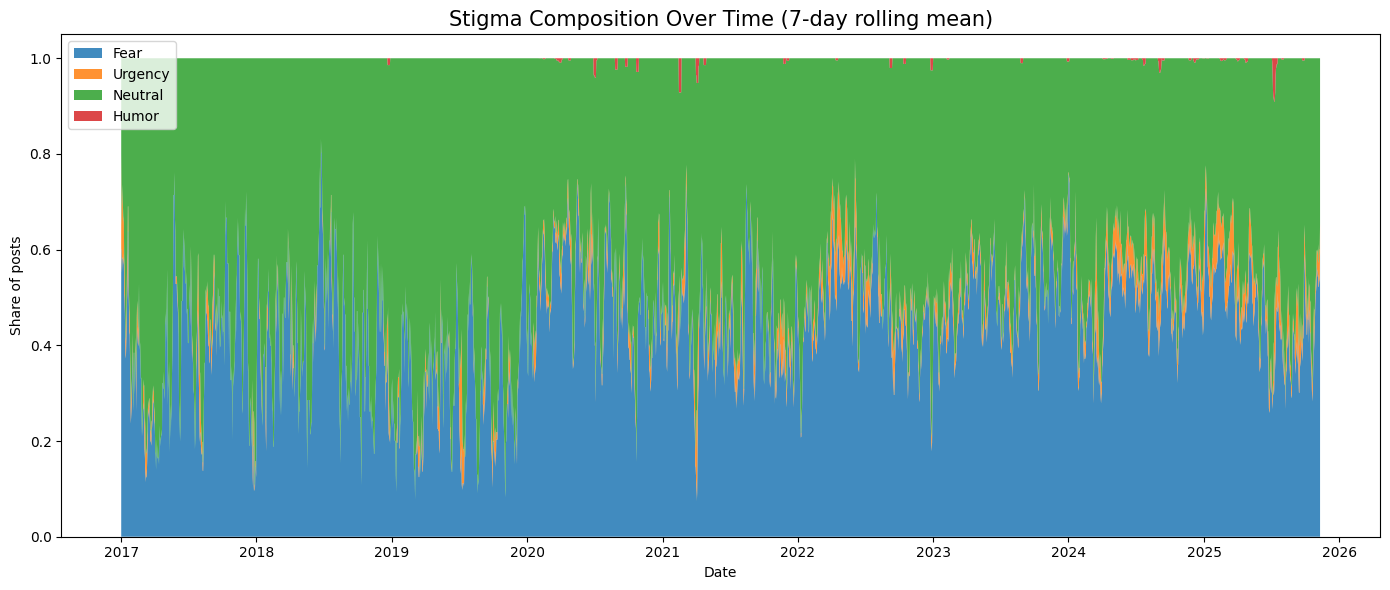

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Parameters
# -------------------------------
stigma_cols = ["stigma_fear", "stigma_urgency", "stigma_neutral", "stigma_humor"]
window_days = 7

# -------------------------------
# Ensure date is datetime
# -------------------------------
df["date"] = pd.to_datetime(df["date"]).dt.date

# -------------------------------
# Daily stigma proportions
# -------------------------------
daily_stigma = (
    df[["date"] + stigma_cols]
    .assign(**{c: df[c].astype(int) for c in stigma_cols})
    .groupby("date")
    .mean()
    .sort_index()
)

# -------------------------------
# Rolling smoothing
# -------------------------------
daily_stigma_smooth = daily_stigma.rolling(window_days, min_periods=1).mean()

# -------------------------------
# Stacked area plot
# -------------------------------
plt.figure(figsize=(14, 6))

plt.stackplot(
    daily_stigma_smooth.index,
    daily_stigma_smooth["stigma_fear"],
    daily_stigma_smooth["stigma_urgency"],
    daily_stigma_smooth["stigma_neutral"],
    daily_stigma_smooth["stigma_humor"],
    labels=["Fear", "Urgency", "Neutral", "Humor"],
    alpha=0.85
)

plt.title("Stigma Composition Over Time (7-day rolling mean)", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Share of posts")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


/var/folders/3t/knnqplg16hv03_0h31dy9sdw0000gq/T/ipykernel_52019/1043115387.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_event[c] = df_event[c].astype(int)
/var/folders/3t/knnqplg16hv03_0h31dy9sdw0000gq/T/ipykernel_52019/1043115387.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_event[c] = df_event[c].astype(int)
/var/folders/3t/knnqplg16hv03_0h31dy9sdw0000gq/T/ipykernel_52019/1043115387.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

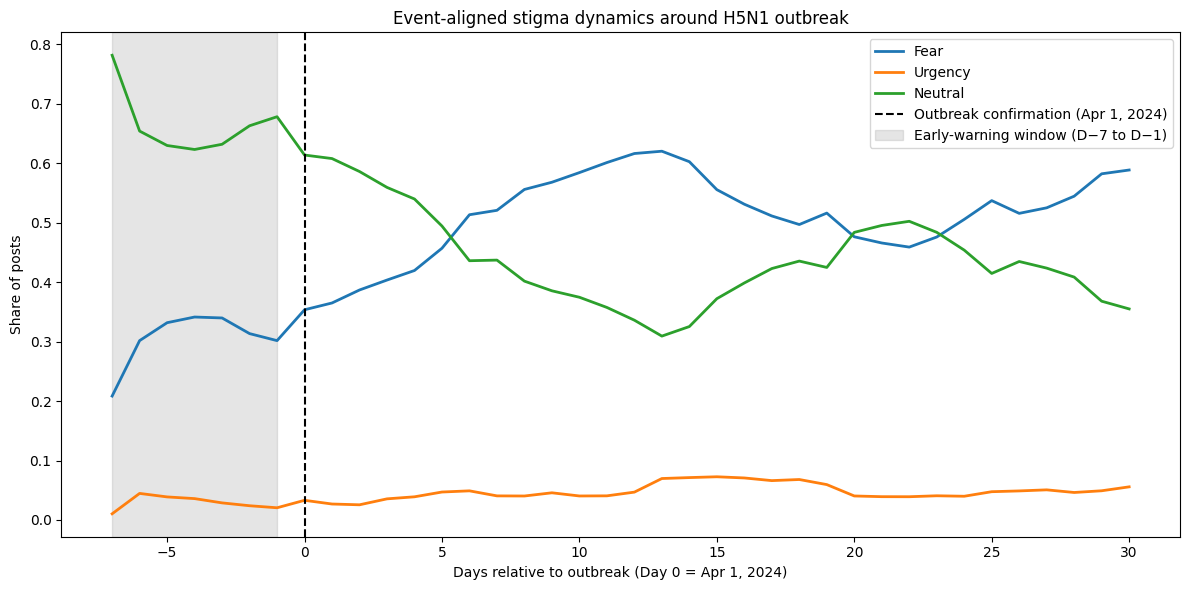

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Parameters
# -------------------------------
OUTBREAK_DATE = pd.Timestamp("2024-04-01")
WINDOW_PRE = 7   # days before outbreak
WINDOW_POST = 30  # days after outbreak
ROLLING_DAYS = 7

stigma_cols = {
    "stigma_fear": "Fear",
    "stigma_urgency": "Urgency",
    "stigma_neutral": "Neutral",
}

# -------------------------------
# Prepare dataframe
# -------------------------------
df = df.copy()
df["date"] = pd.to_datetime(df["date"])
df["event_day"] = (df["date"] - OUTBREAK_DATE).dt.days

# restrict to event window
df_event = df[
    (df["event_day"] >= -WINDOW_PRE) &
    (df["event_day"] <= WINDOW_POST)
]

# ensure numeric
for c in stigma_cols:
    df_event[c] = df_event[c].astype(int)

# -------------------------------
# Aggregate by event day
# -------------------------------
event_daily = (
    df_event
    .groupby("event_day")[list(stigma_cols.keys())]
    .mean()
    .sort_index()
)

# -------------------------------
# Rolling smoothing
# -------------------------------
event_daily_smooth = event_daily.rolling(
    ROLLING_DAYS, min_periods=1
).mean()

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(12, 6))

for col, label in stigma_cols.items():
    plt.plot(
        event_daily_smooth.index,
        event_daily_smooth[col],
        linewidth=2,
        label=label
    )

# outbreak line
plt.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Outbreak confirmation (Apr 1, 2024)"
)

# early-warning window
plt.axvspan(
    -7, -1,
    color="gray",
    alpha=0.2,
    label="Early-warning window (D−7 to D−1)"
)

plt.xlabel("Days relative to outbreak (Day 0 = Apr 1, 2024)")
plt.ylabel("Share of posts")
plt.title("Event-aligned stigma dynamics around H5N1 outbreak")
plt.legend()
plt.tight_layout()
plt.show()


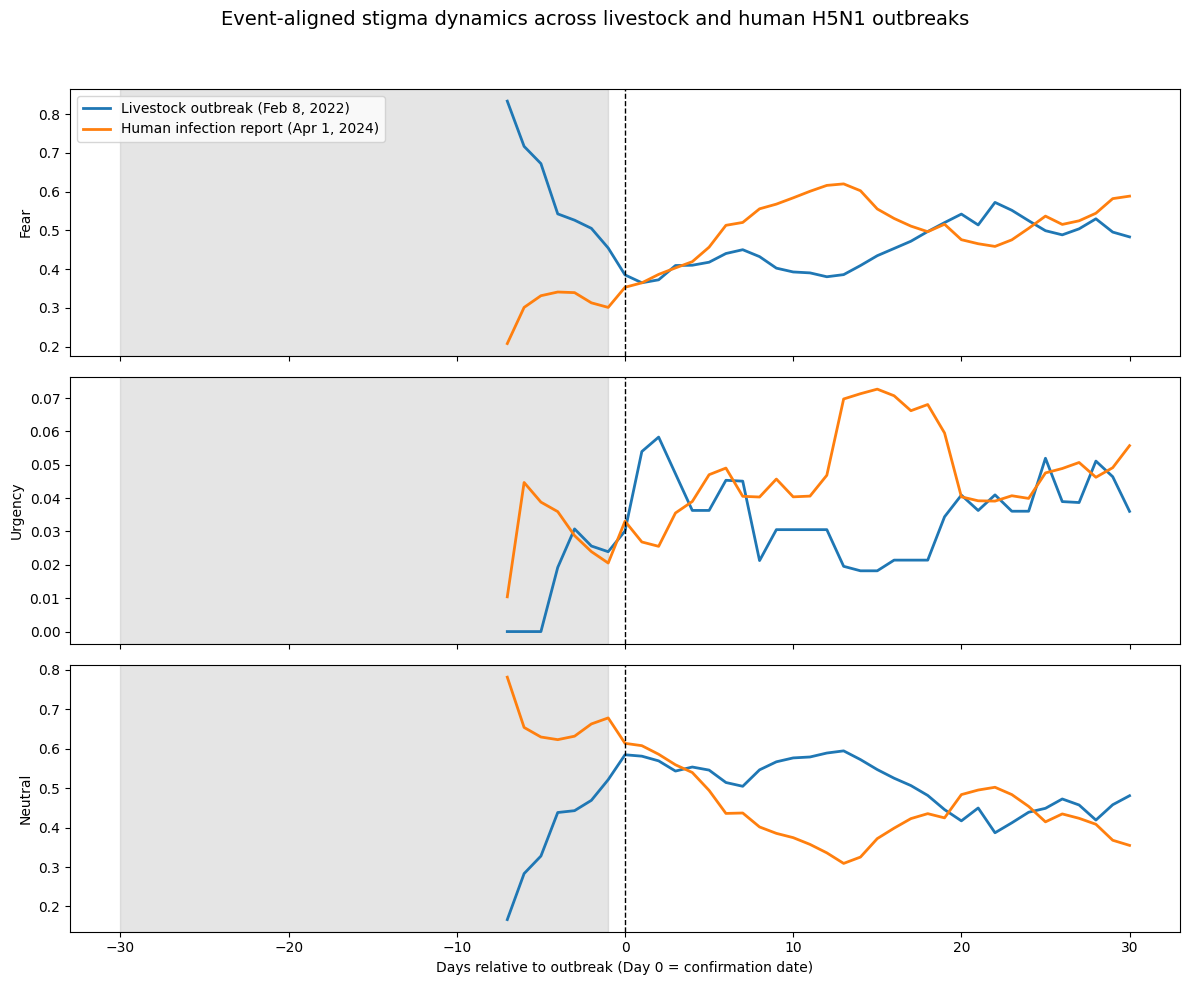

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------
# Parameters
# --------------------------------
OUTBREAKS = {
    "Livestock outbreak (Feb 8, 2022)": pd.Timestamp("2022-02-08"),
    "Human infection report (Apr 1, 2024)": pd.Timestamp("2024-04-01"),
}

WINDOW_PRE = 7
WINDOW_POST = 30
ROLLING_DAYS = 7

stigma_cols = {
    "stigma_fear": "Fear",
    "stigma_urgency": "Urgency",
    "stigma_neutral": "Neutral",
}

# --------------------------------
# Prepare dataframe
# --------------------------------
df = df.copy()
df["date"] = pd.to_datetime(df["date"])

# --------------------------------
# Plot setup
# --------------------------------
fig, axes = plt.subplots(
    nrows=len(stigma_cols),
    ncols=1,
    figsize=(12, 10),
    sharex=True
)

# --------------------------------
# Loop over stigma signals
# --------------------------------
for ax, (col, label) in zip(axes, stigma_cols.items()):

    for outbreak_label, outbreak_date in OUTBREAKS.items():

        # compute relative day
        df["event_day"] = (df["date"] - outbreak_date).dt.days

        df_event = df[
            (df["event_day"] >= -WINDOW_PRE) &
            (df["event_day"] <= WINDOW_POST)
        ]

        # aggregate by relative day
        event_daily = (
            df_event
            .groupby("event_day")[col]
            .mean()
            .sort_index()
            .rolling(ROLLING_DAYS, min_periods=1)
            .mean()
        )

        ax.plot(
            event_daily.index,
            event_daily.values,
            linewidth=2,
            label=outbreak_label
        )

    # outbreak line
    ax.axvline(0, color="black", linestyle="--", linewidth=1)

    # early-warning window
    ax.axvspan(
        -30, -1,
        color="gray",
        alpha=0.2
    )

    ax.set_ylabel(label)

# --------------------------------
# Final formatting
# --------------------------------
axes[-1].set_xlabel("Days relative to outbreak (Day 0 = confirmation date)")
axes[0].legend(loc="upper left")

plt.suptitle(
    "Event-aligned stigma dynamics across livestock and human H5N1 outbreaks",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


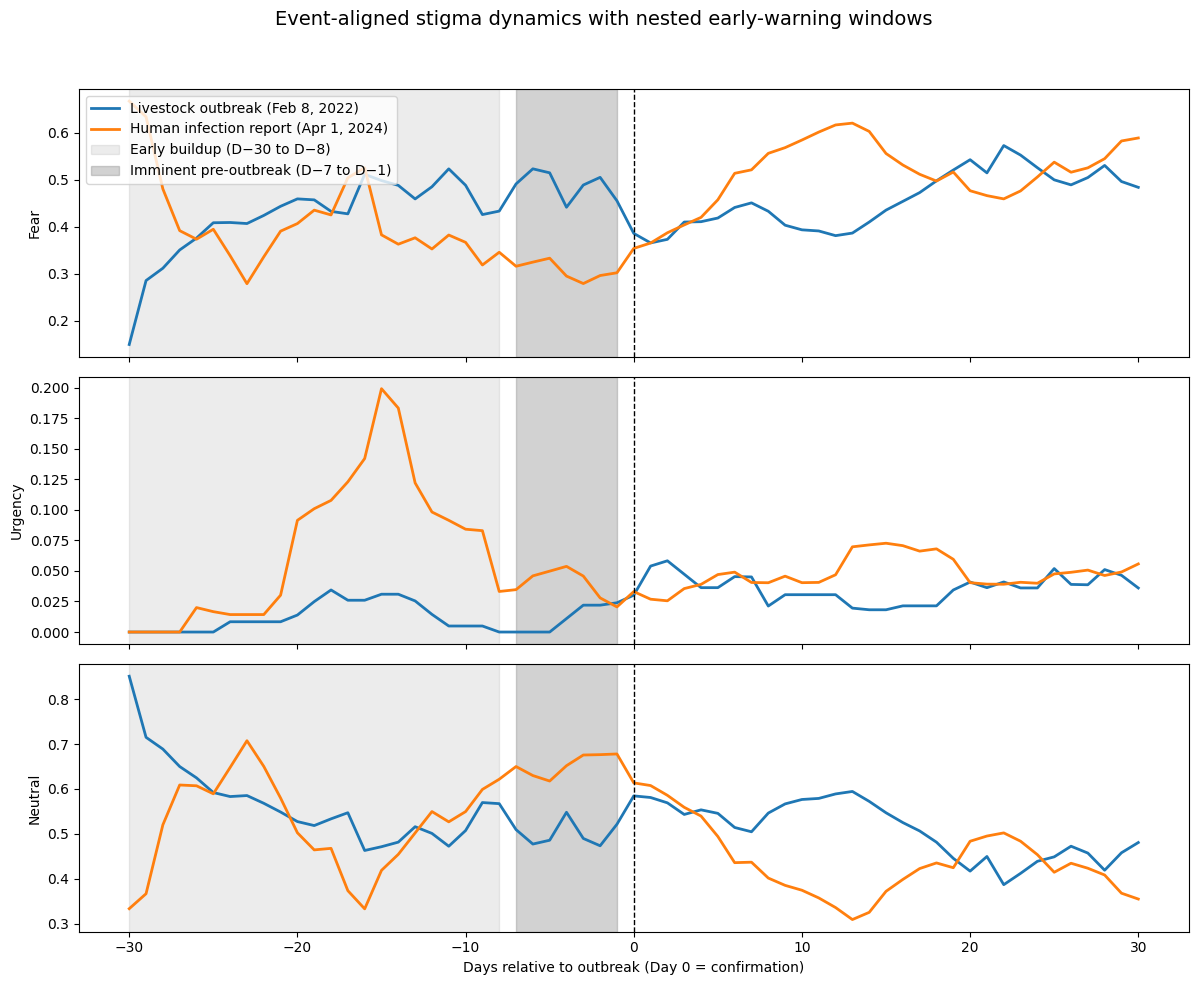

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------
# Parameters
# --------------------------------
OUTBREAKS = {
    "Livestock outbreak (Feb 8, 2022)": pd.Timestamp("2022-02-08"),
    "Human infection report (Apr 1, 2024)": pd.Timestamp("2024-04-01"),
}

WINDOW_PRE = 30
WINDOW_POST = 30
ROLLING_DAYS = 7

stigma_cols = {
    "stigma_fear": "Fear",
    "stigma_urgency": "Urgency",
    "stigma_neutral": "Neutral",
}

# --------------------------------
# Prepare data
# --------------------------------
df = df.copy()
df["date"] = pd.to_datetime(df["date"])

fig, axes = plt.subplots(
    nrows=len(stigma_cols),
    ncols=1,
    figsize=(12, 10),
    sharex=True
)

# --------------------------------
# Plot each stigma signal
# --------------------------------
for ax, (col, label) in zip(axes, stigma_cols.items()):

    for outbreak_label, outbreak_date in OUTBREAKS.items():

        df["event_day"] = (df["date"] - outbreak_date).dt.days

        df_event = df[
            (df["event_day"] >= -WINDOW_PRE) &
            (df["event_day"] <= WINDOW_POST)
        ]

        event_daily = (
            df_event
            .groupby("event_day")[col]
            .mean()
            .sort_index()
            .rolling(ROLLING_DAYS, min_periods=1)
            .mean()
        )

        ax.plot(
            event_daily.index,
            event_daily.values,
            linewidth=2,
            label=outbreak_label
        )

    # Outbreak date
    ax.axvline(0, color="black", linestyle="--", linewidth=1)

    # Long-lead early warning: D-30 to D-8
    ax.axvspan(
        -30, -8,
        color="gray",
        alpha=0.15,
        label="Early buildup (D−30 to D−8)"
    )

    # Imminent phase: D-7 to D-1
    ax.axvspan(
        -7, -1,
        color="gray",
        alpha=0.35,
        label="Imminent pre-outbreak (D−7 to D−1)"
    )

    ax.set_ylabel(label)

# --------------------------------
# Final formatting
# --------------------------------
axes[-1].set_xlabel("Days relative to outbreak (Day 0 = confirmation)")
axes[0].legend(loc="upper left")

plt.suptitle(
    "Event-aligned stigma dynamics with nested early-warning windows",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
